In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

df = pd.read_csv('../data/berek_update.csv')
print(f'Shape: {df.shape}')

print(df.columns.tolist())

Shape: (162804, 26)
['sex', 'contract_type', 'fulltime', 'earnings', 'nuts2_region', 'firm_size_n', 'settlement_type', 'any_supplement', 'firm_size_v1', 'collective_agreement', 'union_presence', 'age', 'tenure_years', 'new_hire', 'education_5cat', 'experience', 'experience_sq', 'overtime_dummy', 'log_earnings', 'firm_size_4cat', 'foreign_majority', 'state_majority', 'industry_13cat', 'position_5cat', 'total_hours', 'log_tenure']


### 1. Multicollinearity Assessment

#### VIF - Continuous Predictors

In [30]:
# Check VIF
numeric_cols = ['experience', 
                'log_tenure', 'age', 'total_hours']

vif_data = pd.DataFrame()
vif_data['Variable'] = numeric_cols
vif_data['VIF'] = [variance_inflation_factor(df[numeric_cols].dropna().values, i) 
                   for i in range(len(numeric_cols))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

      Variable         VIF
2          age  143.399705
0   experience   59.456107
3  total_hours   27.443120
1   log_tenure    4.703811


Initial VIF calculation reveals that `age` is severely collinear with the other 
predictors (VIF = 143), which is expected since age ≈ experience + schooling 
+ 6 years We therefore exclude `age` from the model and rely on 
`experience` to capture the lifecycle earnings profile.

In [31]:
# Recheck VIF
numeric_cols = ['experience', 
                'log_tenure', 'total_hours']

vif_data = pd.DataFrame()
vif_data['Variable'] = numeric_cols
vif_data['VIF'] = [variance_inflation_factor(df[numeric_cols].dropna().values, i) 
                   for i in range(len(numeric_cols))]

print(vif_data.sort_values('VIF', ascending=False).to_string())

      Variable       VIF
2  total_hours  5.711243
0   experience  4.897434
1   log_tenure  4.626801


After dropping `age`, all VIF values fall well within acceptable bounds (max 5.7). 
Note that including `experience_sq` alongside `experience` will 
introduce some inherent correlation between the two terms by construction. This is 
expected and does not constitute problematic multicollinearity, as it reflects the 
intended polynomial specification rather than redundant information.

#### Cramér's V - Categorical Variable Associations

Pearson correlation is not defined for categorical variables. We therefore compute 
Cramér's V for all pairwise combinations of categorical predictors: a chi-squared 
based measure of association bounded between 0 and 1, making it the natural analogue 
of correlation for nominal variables. No pair exceeds 0.47, and the vast majority of 
associations are below 0.15, indicating that multicollinearity among categorical 
predictors is not a concern.

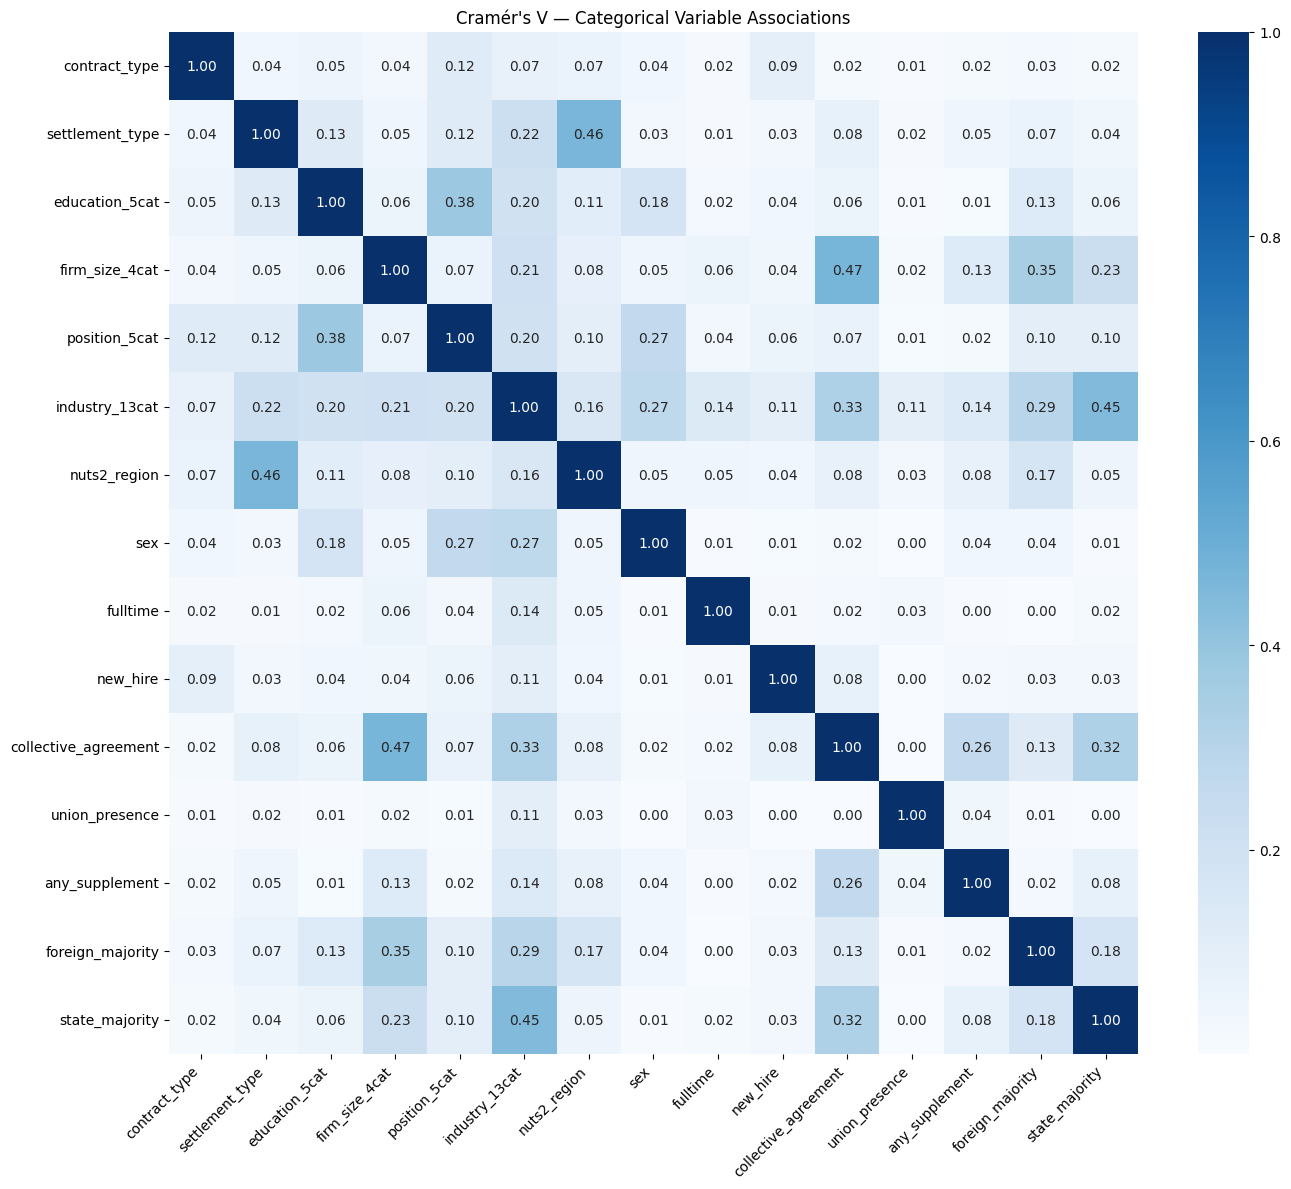

In [32]:
from scipy.stats import chi2_contingency
import itertools

cat_cols = ['contract_type', 'settlement_type', 'education_5cat', 'firm_size_4cat',
            'position_5cat', 'industry_13cat', 'nuts2_region', 'sex', 'fulltime',
            'new_hire', 'collective_agreement', 'union_presence', 'any_supplement',
            'foreign_majority', 'state_majority']

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r-1, k-1))

# Compute Cramer's V for all pairs
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for col1, col2 in itertools.combinations(cat_cols, 2):
    v = cramers_v(df[col1].dropna(), df[col2].dropna())
    cramers_matrix.loc[col1, col2] = v
    cramers_matrix.loc[col2, col1] = v

for col in cat_cols:
    cramers_matrix.loc[col, col] = 1.0

# Heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(cramers_matrix.astype(float), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=cat_cols, yticklabels=cat_cols)
plt.title("Cramér's V — Categorical Variable Associations")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Eta-Squared - Categorical × Continuous Associations

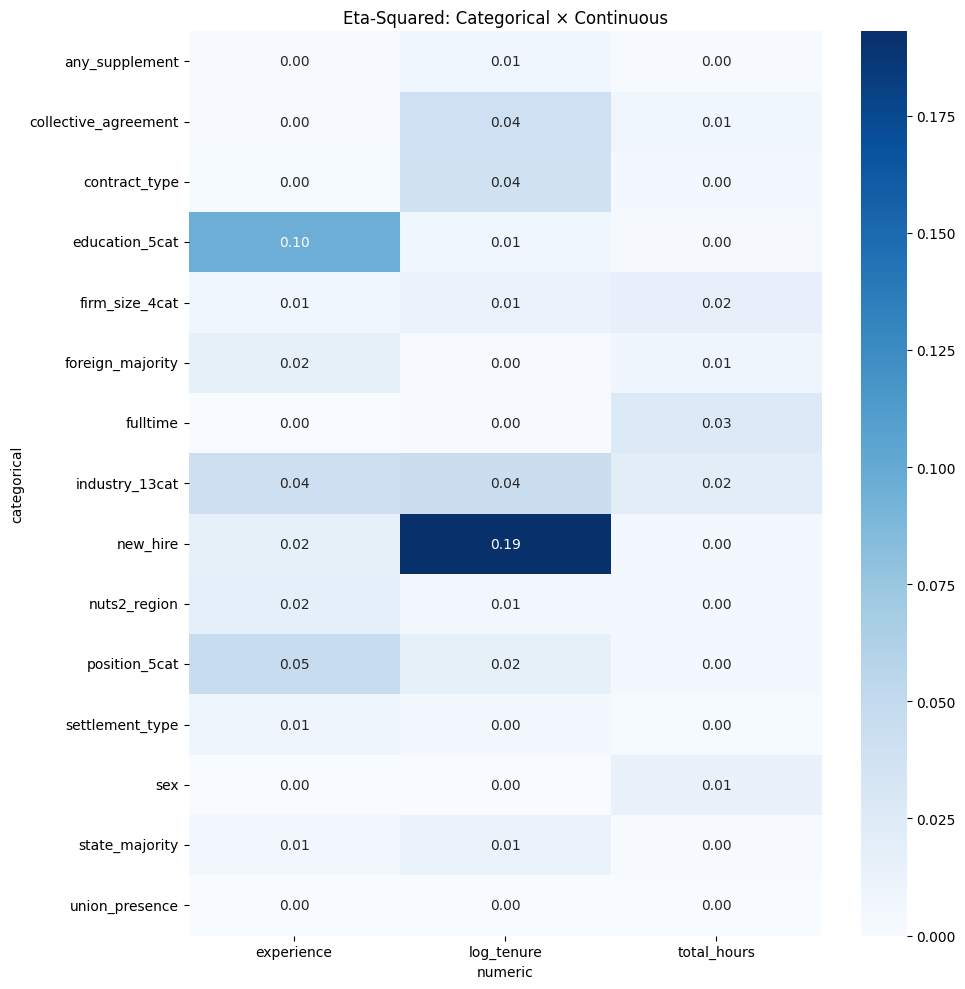

In [33]:
from scipy.stats import f_oneway

cat_cols = ['contract_type', 'settlement_type', 'education_5cat', 'firm_size_4cat',
            'position_5cat', 'industry_13cat', 'nuts2_region', 'sex', 'fulltime',
            'new_hire', 'collective_agreement', 'union_presence', 'any_supplement',
            'foreign_majority', 'state_majority']

numeric_cols = ['experience', 'log_tenure', 'total_hours']

def eta_squared(cat, num):
    groups = [num[cat == c].dropna() for c in cat.dropna().unique()]
    grand_mean = num.mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_total = sum((num - grand_mean)**2)
    return ss_between / ss_total

results = []
for c in cat_cols:
    for n in numeric_cols:
        eta2 = eta_squared(df[c], df[n].dropna())
        results.append({'categorical': c, 'numeric': n, 'eta_squared': round(eta2, 3)})

eta_df = pd.DataFrame(results).pivot(index='categorical', columns='numeric', values='eta_squared')

plt.figure(figsize=(10, 10))
sns.heatmap(eta_df, annot=True, fmt='.2f', cmap='Blues')
plt.title('Eta-Squared: Categorical × Continuous')
plt.tight_layout()
plt.show()

To assess associations between categorical and continuous predictors, we compute 
eta-squared (η²), which measures the proportion of variance in a continuous variable 
explained by the groupings of a categorical variable, the natural analogue of R² for 
this type of association. The highest values are `new_hire` × `log_tenure` (0.19) and 
`education_5cat` × `general_experience` (0.12), both of which are economically 
intuitive rather than indicative of harmful collinearity. All other pairs are below 
0.07, confirming that categorical and continuous predictors carry largely independent 
information.

### Model Specification

We estimate two OLS models. The baseline model includes all main effects without 
interactions. `union_presence` is excluded from the second model as it was not significant 
in the baseline (p = 0.99). The interaction model adds ownership × worker characteristic 
interactions motivated by the EDA, where foreign-majority firms showed visually distinct 
slopes for experience, tenure, total hours, education, and position.

In [34]:
import statsmodels.formula.api as smf

baseline_formula = """
log_earnings ~ foreign_majority + state_majority
             + experience + experience_sq + log_tenure
             + total_hours + sex + education_5cat + position_5cat
             + contract_type + fulltime + any_supplement
             + firm_size_4cat + collective_agreement + union_presence
             + industry_13cat + settlement_type + nuts2_region
"""

baseline_model = smf.ols(baseline_formula, data=df).fit()
print(baseline_model.summary2())

                           Results: Ordinary least squares
Model:                    OLS                    Adj. R-squared:           0.552      
Dependent Variable:       log_earnings           AIC:                      160310.2092
Date:                     2026-05-14 00:14       BIC:                      160760.2228
No. Observations:         162804                 Log-Likelihood:           -80110.    
Df Model:                 44                     F-statistic:              4569.      
Df Residuals:             162759                 Prob (F-statistic):       0.00       
R-squared:                0.553                  Scale:                    0.15669    
--------------------------------------------------------------------------------------
                                       Coef.  Std.Err.    t     P>|t|   [0.025  0.975]
--------------------------------------------------------------------------------------
Intercept                             11.5887   0.0381 304.0680 0.0000 

**Key coefficients: baseline model:**
- `foreign_majority`: +0.22 (~25% unconditional wage premium)
- `state_majority`: +0.02 (~3% premium, modest but significant)
- `sex[male]`: +0.14 (~15% gender gap)
- `education[tertiary]`: +0.56 (~75% premium over primary incomplete)
- `position[manual]`: -0.53 relative to top management

In [36]:
interaction_formula = """
log_earnings ~ foreign_majority + state_majority
             + experience + experience_sq + log_tenure
             + total_hours + sex + education_5cat + position_5cat
             + contract_type + fulltime + any_supplement
             + firm_size_4cat + collective_agreement
             + industry_13cat + settlement_type + nuts2_region
             + foreign_majority:experience
             + foreign_majority:total_hours
             + foreign_majority:log_tenure
             + foreign_majority:education_5cat
             + foreign_majority:position_5cat
"""

interaction_model = smf.ols(interaction_formula, data=df).fit()
print(f'R-squared: {interaction_model.rsquared:.4f}')
print(f'Adj. R-squared: {interaction_model.rsquared_adj:.4f}')
print(f'N observations: {int(interaction_model.nobs)}')
print(f'AIC: {interaction_model.aic:.2f}')
print(f'BIC: {interaction_model.bic:.2f}')
print(interaction_model.summary2())

R-squared: 0.5669
Adj. R-squared: 0.5668
N observations: 162804
AIC: 155048.61
BIC: 155598.63
                                    Results: Ordinary least squares
Model:                          OLS                          Adj. R-squared:                 0.567      
Dependent Variable:             log_earnings                 AIC:                            155048.6128
Date:                           2026-05-14 00:17             BIC:                            155598.6295
No. Observations:               162804                       Log-Likelihood:                 -77469.    
Df Model:                       54                           F-statistic:                    3945.      
Df Residuals:                   162749                       Prob (F-statistic):             0.00       
R-squared:                      0.567                        Scale:                          0.15170    
-------------------------------------------------------------------------------------------------------

**Key coefficients - interaction model:**
- `foreign_majority` main effect rises to +0.43, now interpreted as the premium 
  for top management specifically
- `foreign_majority × experience`: +0.003 -> higher returns to experience at foreign firms
- `foreign_majority × log_tenure`: +0.017 -> higher tenure premium at foreign firms
- `foreign_majority × education[tertiary]`: +0.30 -> foreign firms disproportionately 
  reward tertiary-educated workers
- `foreign_majority × position[manual]`: -0.74 -> the foreign premium nearly vanishes 
  for manual workers, confirming that ownership wage gaps are concentrated at the top 
  of the job hierarchy

In [38]:
print(f'Baseline    - AIC: {baseline_model.aic:.0f}, BIC: {baseline_model.bic:.0f}')
print(f'Interaction -  AIC: {interaction_model.aic:.0f}, BIC: {interaction_model.bic:.0f}')

Baseline    - AIC: 160310, BIC: 160760
Interaction -  AIC: 155049, BIC: 155599


Both information criteria favor the interaction model decisively: AIC drops from 
160,310 to 155,049 and BIC from 160,760 to 155,599, a reduction of over 5,000 units 
in both cases. 